In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
import kagglehub
from kagglehub import KaggleDatasetAdapter

# Set the path to the file you'd like to load
# You need to specify a valid file name with a supported extension.
# For example, let's load '2019-Oct.csv' from the dataset.
file_path = "2019-Oct.csv"

# Load the latest version
df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "mkechinov/ecommerce-behavior-data-from-multi-category-store",
  file_path
)

print("First 5 records:", df.head())

/tmp/ipykernel_474/662477490.py:10: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


100%|██████████| 1.61G/1.61G [00:23<00:00, 73.0MB/s]

Extracting zip of 2019-Oct.csv...


First 5 records:                 event_time event_type  product_id          category_id  \
0  2019-10-01 00:00:00 UTC       view    44600062  2103807459595387724   
1  2019-10-01 00:00:00 UTC       view     3900821  2053013552326770905   
2  2019-10-01 00:00:01 UTC       view    17200506  2053013559792632471   
3  2019-10-01 00:00:01 UTC       view     1307067  2053013558920217191   
4  2019-10-01 00:00:04 UTC       view     1004237  2053013555631882655   

                         category_code     brand    price    user_id  \
0                                  NaN  shiseido    35.79  541312140   
1  appliances.environment.water_heater      aqua    33.20  554748717   
2           furniture.living_room.sofa       NaN   543.10  519107250   
3                   computers.notebook    lenovo   251.74  550050854   
4               electronics.smartphone     apple  1081.98  535871217   

                           user_session  
0  72d76fde-8bb3-4e00-8c23-a032dfed738c  
1  9333dfbd-b87a-4708

In [4]:
df["event_type"].value_counts()

,count
event_type,
view,40779399
cart,926516
purchase,742849


In [5]:
views = df[df["event_type"]=="view"].shape[0]
carts = df[df["event_type"]=="cart"].shape[0]
purchases = df[df["event_type"]=="purchase"].shape[0]

print("Views:", views)
print("Carts:", carts)
print("Purchases:", purchases)

Views: 40779399
Carts: 926516
Purchases: 742849


In [6]:
cart_abandonment = (carts - purchases) / carts
print("Cart Abandonment Rate:", round(cart_abandonment*100,2), "%")

Cart Abandonment Rate: 19.82 %


It take like a user, not a certain event, now consider events

In [8]:
total_sessions = df["user_session"].nunique()

sessions_view = df[df["event_type"] == "view"]["user_session"].nunique()
sessions_cart = df[df["event_type"] == "cart"]["user_session"].nunique()
sessions_purchase = df[df["event_type"] == "purchase"]["user_session"].nunique()

print("Total unique sessions:", total_sessions)
print("Sessions with view:", sessions_view)
print("Sessions with cart:", sessions_cart)
print("Sessions with purchase:", sessions_purchase)

Total unique sessions: 9244421
Sessions with view: 9242653
Sessions with cart: 573097
Sessions with purchase: 629560


In [9]:
cart_df = df[df["event_type"] == "cart"]

top_cart_categories = cart_df["category_code"].value_counts().head(10)

print(top_cart_categories)

category_code
electronics.smartphone              549765
electronics.audio.headphone          51143
electronics.video.tv                 36224
appliances.kitchen.washer            21977
electronics.clocks                   20344
appliances.environment.vacuum        17263
computers.notebook                   15627
appliances.kitchen.refrigerators     13126
electronics.tablet                    9140
electronics.telephone                 5342
Name: count, dtype: int64


In [10]:
purchase_df = df[df["event_type"] == "purchase"]

top_purchase_categories = purchase_df["category_code"].value_counts().head(10)

print(top_purchase_categories)

category_code
electronics.smartphone              338018
electronics.audio.headphone          30503
electronics.video.tv                 21565
electronics.clocks                   17906
appliances.kitchen.washer            16148
computers.notebook                   15590
appliances.environment.vacuum        12378
appliances.kitchen.refrigerators     11218
electronics.tablet                    5603
auto.accessories.player               4647
Name: count, dtype: int64


In [11]:
cart_counts = cart_df["category_code"].value_counts()
purchase_counts = purchase_df["category_code"].value_counts()

comparison = pd.DataFrame({
    "Cart Events": cart_counts,
    "Purchase Events": purchase_counts
}).fillna(0)

comparison["Abandoned Carts"] = comparison["Cart Events"] - comparison["Purchase Events"]

comparison_sorted = comparison.sort_values("Abandoned Carts", ascending=False)

print(comparison_sorted.head(10))

                                  Cart Events  Purchase Events  \
category_code                                                    
electronics.smartphone               549765.0           338018   
electronics.audio.headphone           51143.0            30503   
electronics.video.tv                  36224.0            21565   
appliances.kitchen.washer             21977.0            16148   
appliances.environment.vacuum         17263.0            12378   
electronics.tablet                     9140.0             5603   
electronics.clocks                    20344.0            17906   
appliances.kitchen.refrigerators      13126.0            11218   
auto.accessories.alarm                 4100.0             2441   
electronics.telephone                  5342.0             3738   

                                  Abandoned Carts  
category_code                                      
electronics.smartphone                   211747.0  
electronics.audio.headphone               20640.0  

In [12]:
cart_revenue = cart_df.groupby("category_code")["price"].sum()
purchase_revenue = purchase_df.groupby("category_code")["price"].sum()

revenue_comparison = pd.DataFrame({
    "Cart Revenue": cart_revenue,
    "Purchase Revenue": purchase_revenue
}).fillna(0)

revenue_comparison["Abandoned Revenue"] = revenue_comparison["Cart Revenue"] - revenue_comparison["Purchase Revenue"]

top_abandoned_revenue = revenue_comparison.sort_values("Abandoned Revenue", ascending=False)

print(top_abandoned_revenue.head(10))

                                  Cart Revenue  Purchase Revenue  \
category_code                                                      
electronics.smartphone            2.353282e+08      1.570496e+08   
electronics.video.tv              1.427978e+07      8.423408e+06   
electronics.audio.headphone       5.967964e+06      3.539127e+06   
appliances.kitchen.washer         6.848704e+06      4.658647e+06   
electronics.clocks                6.461084e+06      4.818305e+06   
appliances.kitchen.refrigerators  5.089855e+06      3.830077e+06   
appliances.environment.vacuum     2.516269e+06      1.716425e+06   
electronics.tablet                2.184213e+06      1.610974e+06   
computers.notebook                9.548366e+06      8.979887e+06   
auto.accessories.alarm            5.473187e+05      3.359793e+05   

                                  Abandoned Revenue  
category_code                                        
electronics.smartphone                  78278546.67  
electronics.video.tv 

In [13]:
recovery_rates = [0.03, 0.05, 0.10]

smartphone_abandoned = revenue_comparison.loc["electronics.smartphone", "Abandoned Revenue"]

for rate in recovery_rates:
    recovered_revenue = smartphone_abandoned * rate
    print(f"Recovery at {int(rate*100)}%:", round(recovered_revenue,2))

Recovery at 3%: 2348356.4
Recovery at 5%: 3913927.33
Recovery at 10%: 7827854.67


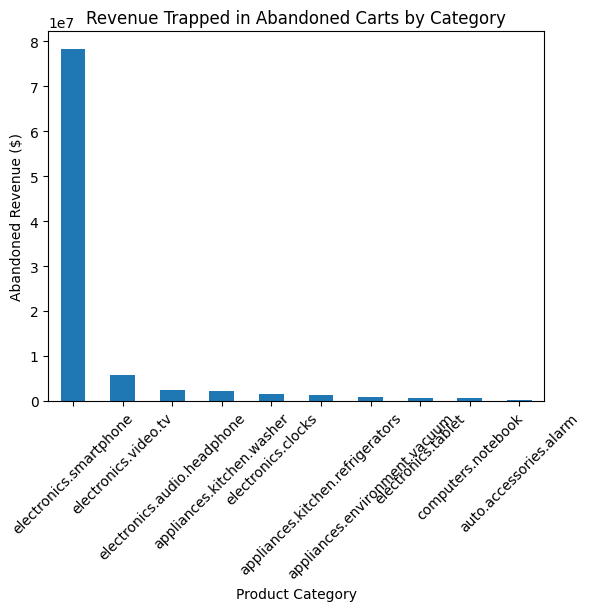

In [14]:
top_abandoned_revenue.head(10)["Abandoned Revenue"].plot(kind="bar")

plt.title("Revenue Trapped in Abandoned Carts by Category")
plt.ylabel("Abandoned Revenue ($)")
plt.xlabel("Product Category")
plt.xticks(rotation=45)

plt.show()

In [15]:
price_view = df[df["event_type"]=="view"]["price"].mean()
price_cart = df[df["event_type"]=="cart"]["price"].mean()
price_purchase = df[df["event_type"]=="purchase"]["price"].mean()

print("Average viewed product price:", price_view)
print("Average cart product price:", price_cart)
print("Average purchased product price:", price_purchase)

Average viewed product price: 288.9847450861149
Average cart product price: 333.829992121021
Average purchased product price: 309.5615694037415


In [16]:
session_views = df[df["event_type"]=="view"].groupby("user_session").size()

print(session_views.describe())

count    9.242653e+06
mean     4.412088e+00
std      6.660797e+00
min      1.000000e+00
25%      1.000000e+00
50%      2.000000e+00
75%      5.000000e+00
max      1.158000e+03
dtype: float64


In [17]:
import os

folders = [
    "cart-abandonment-intelligence/data",
    "cart-abandonment-intelligence/notebooks",
    "cart-abandonment-intelligence/dashboard",
    "cart-abandonment-intelligence/images"
]

for folder in folders:
    os.makedirs(folder, exist_ok=True)

with open("cart-abandonment-intelligence/README.md", "w") as f:
    f.write("# Cart Abandonment Intelligence\n")

print("Project structure created successfully.")

Project structure created successfully.


In [18]:
import os
os.getcwd()

'/content'